<a href="https://colab.research.google.com/github/Amanparijoshi/marketing-analytics-ml-projects/blob/main/maarket.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Facebook Live Sellers in Thailand – Case Study



Saving Facebook_Marketplace_data.csv to Facebook_Marketplace_data.csv


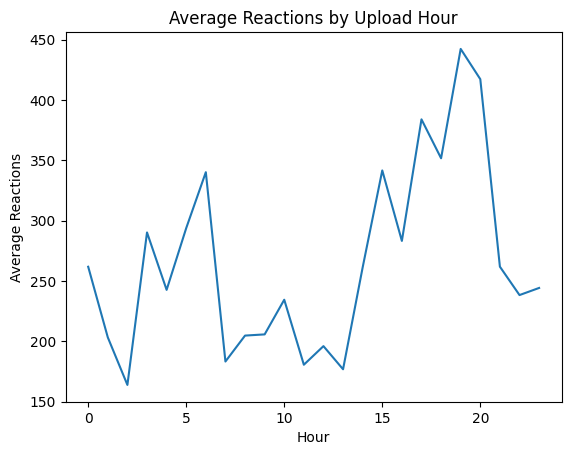

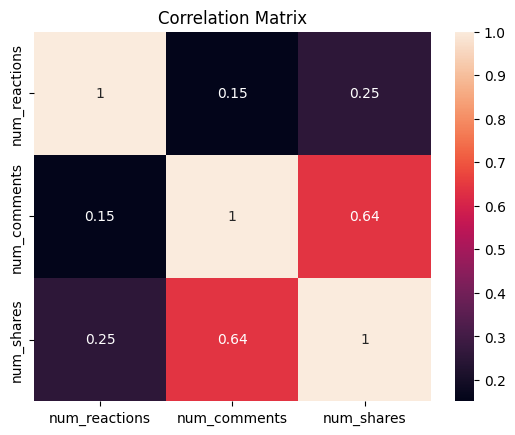

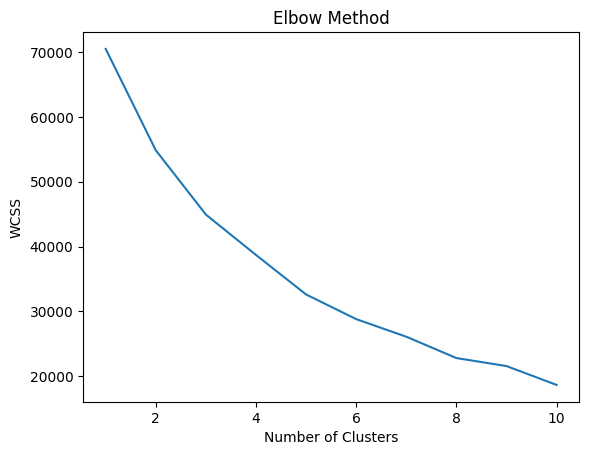

Silhouette Score: 0.6590656446499957


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

from google.colab import files
uploaded = files.upload()

df = pd.read_csv("Facebook_Marketplace_data.csv")
df.head()
df = df.loc[:, ~df.columns.str.contains('^Column')]
df.isnull().sum()
df['status_published'] = pd.to_datetime(df['status_published'])

df['hour'] = df['status_published'].dt.hour
df['day'] = df['status_published'].dt.day_name()

df.head()
hourly_reactions = df.groupby('hour')['num_reactions'].mean()

plt.figure()
hourly_reactions.plot()
plt.title("Average Reactions by Upload Hour")
plt.xlabel("Hour")
plt.ylabel("Average Reactions")
plt.show()
correlation = df[['num_reactions','num_comments','num_shares']].corr()

plt.figure()
sns.heatmap(correlation, annot=True)
plt.title("Correlation Matrix")
plt.show()

correlation
df['status_type'].value_counts()
df.groupby('status_type')[['num_reactions','num_comments','num_shares']].mean()
le = LabelEncoder()
df['status_type_encoded'] = le.fit_transform(df['status_type'])
features = df[['status_type_encoded',
               'num_reactions',
               'num_comments',
               'num_shares',
               'num_likes',
               'num_loves',
               'num_wows',
               'num_hahas',
               'num_sads',
               'num_angrys']]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

plt.figure()
plt.plot(range(1,11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_features)

df.head()
df['Cluster'].value_counts()
df.groupby('Cluster')[['num_reactions','num_comments','num_shares']].mean()
score = silhouette_score(scaled_features, df['Cluster'])
print("Silhouette Score:", score)


Saving advertising_sales_data.xlsx to advertising_sales_data (6).xlsx
Columns in dataset: Index(['Campaign', 'TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

First 5 Rows:
  Campaign     TV  Radio  Newspaper  Sales
0    camp1  230.1   37.8       69.2   22.1
1    camp2   44.5   39.3       45.1   10.4
2    camp3   17.2   45.9       69.3   12.0
3    camp4  151.5   41.3       58.5   16.5
4    camp5  180.8   10.8       58.4   17.9

Q1: Average TV Spend: 147.0425

Q2: Correlation Radio & Sales: 0.3496507429302875

Q3: Correlation with Sales:
Sales        1.000000
TV           0.901208
Radio        0.349651
Newspaper    0.157960
Name: Sales, dtype: float64

Q4: Model Performance
R2 Score: 0.9059117026092904
MSE: 2.9074318865000555


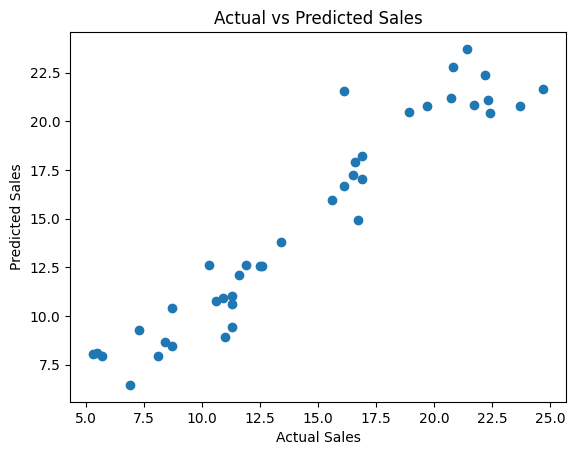


Q5: Predicted Sales for (200, 40, 50): 19.871049209206635

Q6: R2 After Scaling: 0.9059117026092904

Q7: R2 Using Radio & Newspaper Only: 0.10998637077378115


In [ ]:

# SALES PREDICTION



from google.colab import files
uploaded = files.upload()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler


df = pd.read_excel("advertising_sales_data.xlsx")

df.columns = df.columns.str.strip()

print("Columns in dataset:", df.columns)
print("\nFirst 5 Rows:")
print(df.head())
df.columns = df.columns.str.strip()
df = df.fillna(df.mean(numeric_only=True))



print("\nQ1: Average TV Spend:", df['TV'].mean())


print("\nQ2: Correlation Radio & Sales:", df['Radio'].corr(df['Sales']))


print("\nQ3: Correlation with Sales:")
print(df.select_dtypes(include=['number']).corr()['Sales'].sort_values(ascending=False))



X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nQ4: Model Performance")
print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))


plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()


new_data = pd.DataFrame([[200, 40, 50]], columns=['TV','Radio','Newspaper'])
prediction = model.predict(new_data)

print("\nQ5: Predicted Sales for (200, 40, 50):", prediction[0])


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

model_scaled = LinearRegression()
model_scaled.fit(X_train_s, y_train_s)

y_pred_s = model_scaled.predict(X_test_s)

print("\nQ6: R2 After Scaling:", r2_score(y_test_s, y_pred_s))

X_rn = df[['Radio', 'Newspaper']]

X_train_rn, X_test_rn, y_train_rn, y_test_rn = train_test_split(X_rn, y, test_size=0.2, random_state=42)

model_rn = LinearRegression()
model_rn.fit(X_train_rn, y_train_rn)

y_pred_rn = model_rn.predict(X_test_rn)

print("\nQ7: R2 Using Radio & Newspaper Only:", r2_score(y_test_rn, y_pred_rn))


